In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from skimage.exposure import match_histograms

sys.path.append("../..")
from src import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Video Fusion With Discrete Cosine Transform (DCT)
Can we augment a denoiser output using a sliding window on the raw footage and DCT video fusion?

This can be used to **reduce the number of training steps for deep-learning models**, which are known to be expensive to train. This is the case with DeepCAD-RT, which uses a 3D UNet.

In [144]:
patch_t = 600
patch_xy = 256
avg_win = 2048

In [145]:
meta = DATASETS["synthetic"]
y_path = DATASETS["synthetic"].dir / "deepcad_E_10.tif"
x, y, gt = (Recording(_, max_frames=2048, norm=True) for _ in [meta.x, meta.dir / "deepcad_15.tiff", meta.gt])
RES_DIR = mkdir("results/synthetic/")

In [146]:
x_p = x.np[:patch_t, :patch_xy, :patch_xy]
y_hat_p = y.np[:patch_t, :patch_xy, :patch_xy]
gt_p = gt.np[:patch_t, :patch_xy, :patch_xy]
y_bar_p = x.avg_fast(avg_win)[:patch_t, :patch_xy, :patch_xy]

In [ ]:
def match(src, trg):
    low = np.quantile(src.flatten(), 0.25)
    high = np.quantile(src.flatten(), 0.75)
    t_low = np.quantile(trg.flatten(), 0.25)
    t_high = np.quantile(trg.flatten(), 0.75)
    denom = np.clip(high - low, min=1e-6)
    a = (t_high - t_low) / denom
    b = t_low - a * low
    return np.clip(a * src + b, 0, 1)


def make_mask(patch_t, t0, δt):
    t = np.arange(patch_t)
    M = np.clip((t - (t0 - δt)) / (2 * δt), 0, 1)  # grows from 0→1 around t0
    return 1 - M


def fuse_dft(y_bar, y_hat, M):
    Y_bar = np.fft.rfft(y_bar, axis=0)
    Y_hat = np.fft.rfft(y_hat, axis=0)
    Y_bar_abs = np.abs(Y_bar)
    Y_hat_abs = np.abs(Y_hat)
    Y_bar_abs[0] = match_histograms(Y_bar_abs[0], Y_hat_abs[0])

    M = M.reshape(-1, 1, 1)
    Y_abs = M * Y_bar_abs + (1 - M) * Y_hat_abs
    Y = Y_abs * np.exp(1j * np.angle(Y_hat))
    return np.fft.irfft(Y, axis=0).real

<Axes: xlabel='Frequency ($\\omega$)', ylabel='Convex comb. coeff. ($M_\\omega$)'>

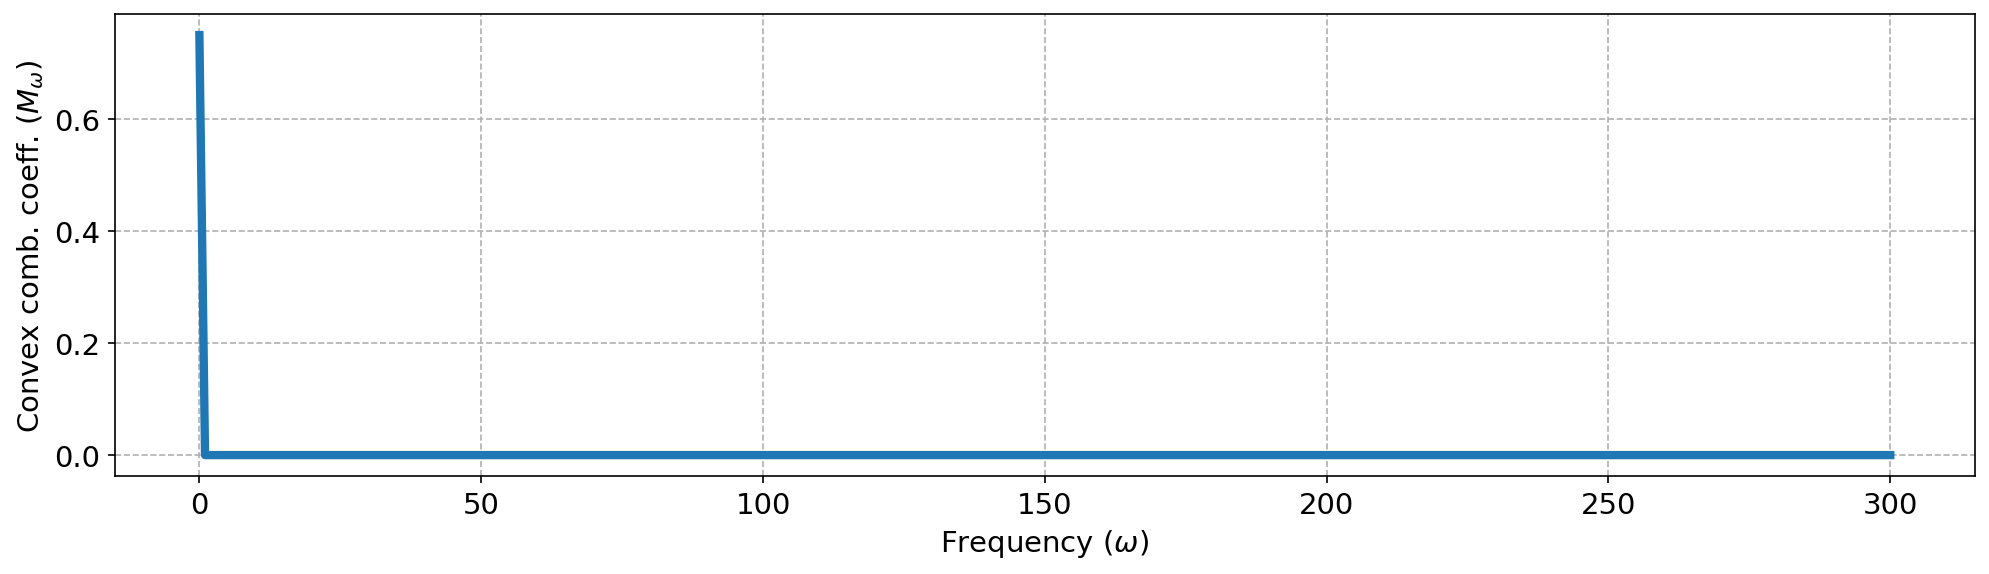

In [197]:
M = make_mask(patch_t//2+1, t0=0.25, δt=0.5)
plt.figure(figsize=(16, 4), dpi=150)
pd.Series(M).plot(linewidth=4, xlabel="Frequency ($\\omega$)", ylabel="Convex comb. coeff. ($M_\\omega$)")

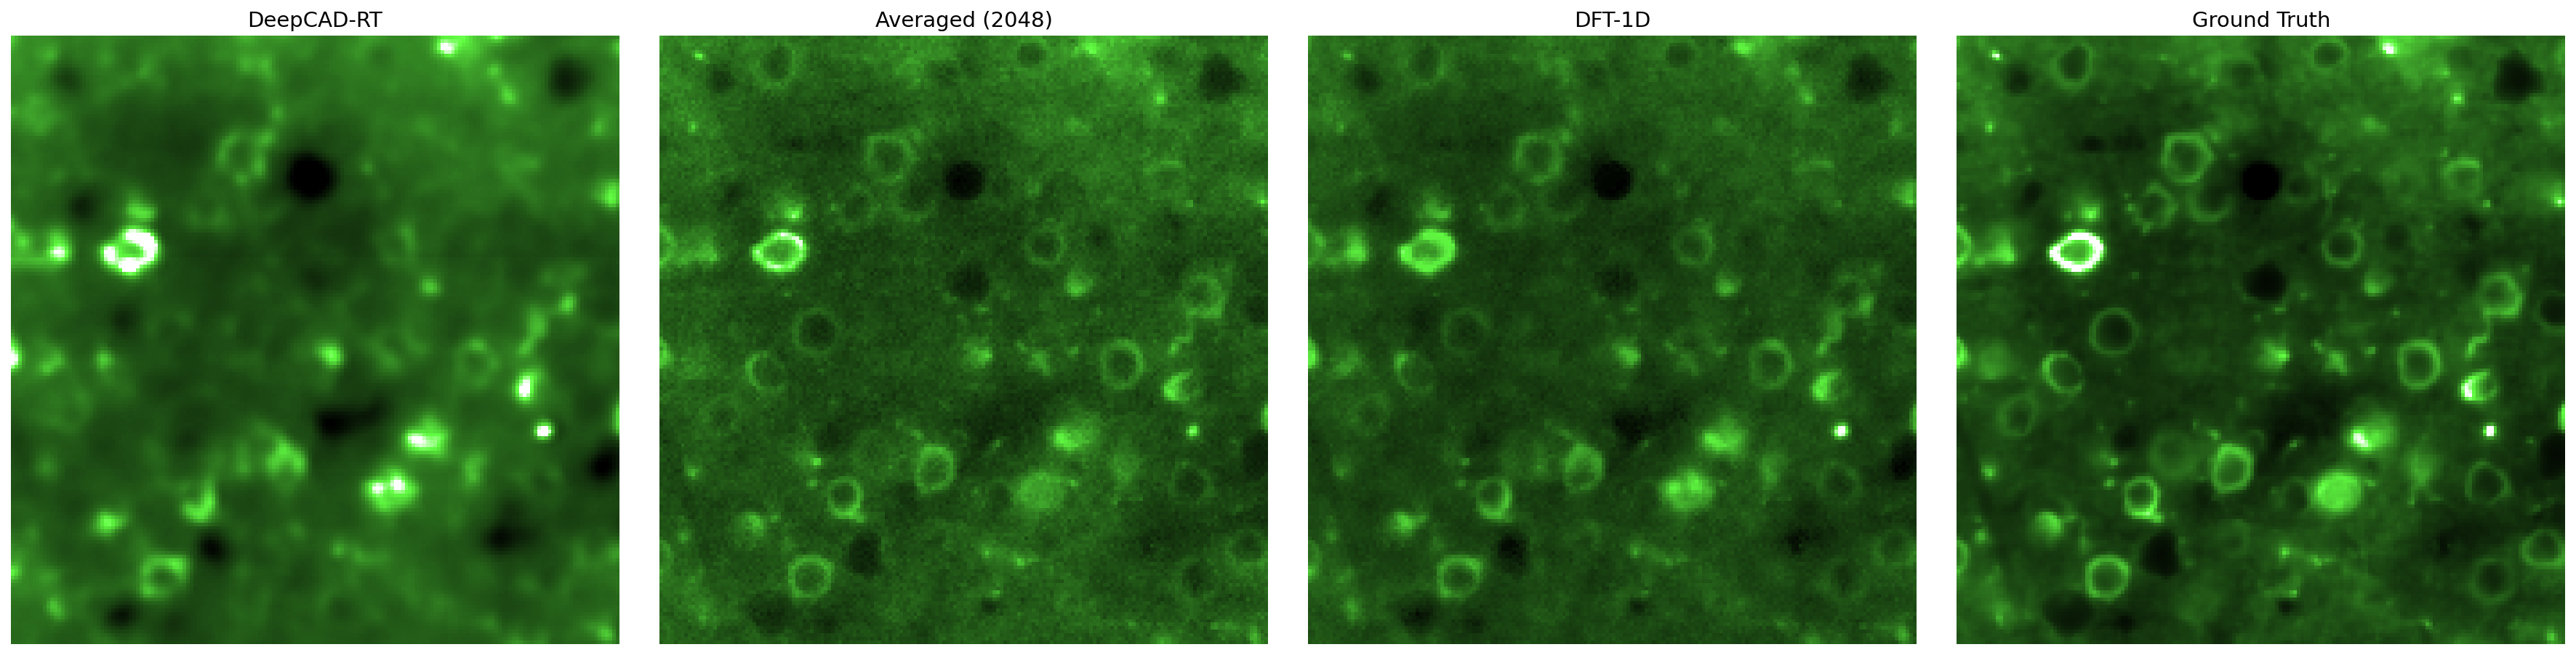

In [198]:
fused = fuse_dft(y_bar_p, y_hat_p, M)
i=100
imshow({
    "DeepCAD-RT":y_hat_p[i],
    f"Averaged ({avg_win})":y_bar_p[i],
    "DFT-1D":fused[i],
    "Ground Truth":gt_p[i],
}, size=6, zoom=1.5)

## $PSNR_{3D}$ and $SSIM_{3D}$ Metrics

In [181]:
psnr3d(y_hat_p, gt_p), ssim3d(y_hat_p, gt_p)

(np.float64(22.55280562917796), 0.6832917332649231)

In [199]:
psnr3d(fused, gt_p), ssim3d(fused, gt_p)

(np.float64(23.176644788182145), 0.7784125208854675)

## Temporal analysis

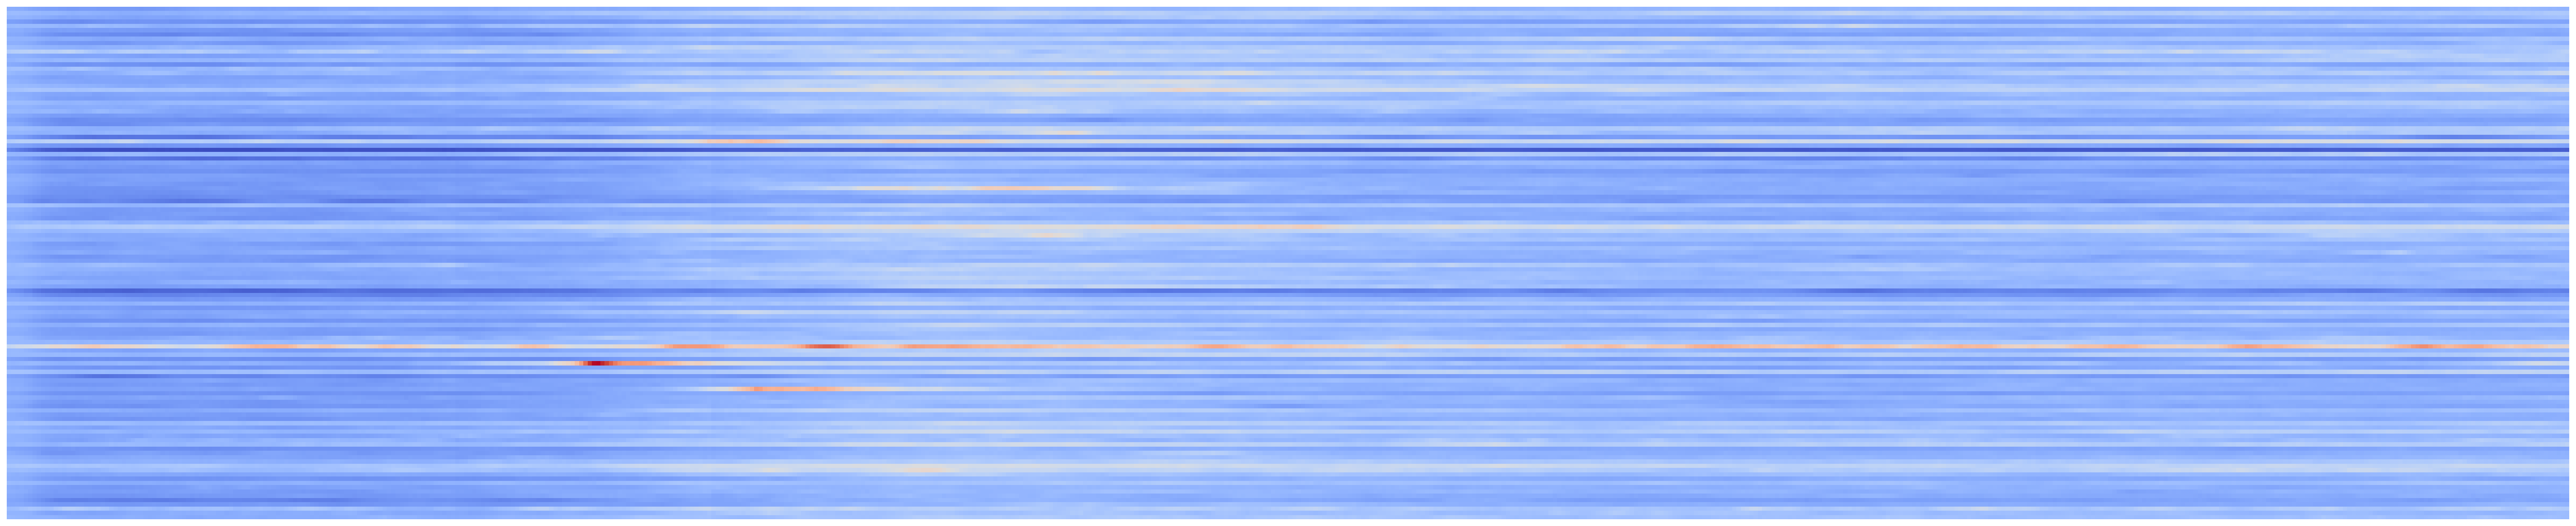

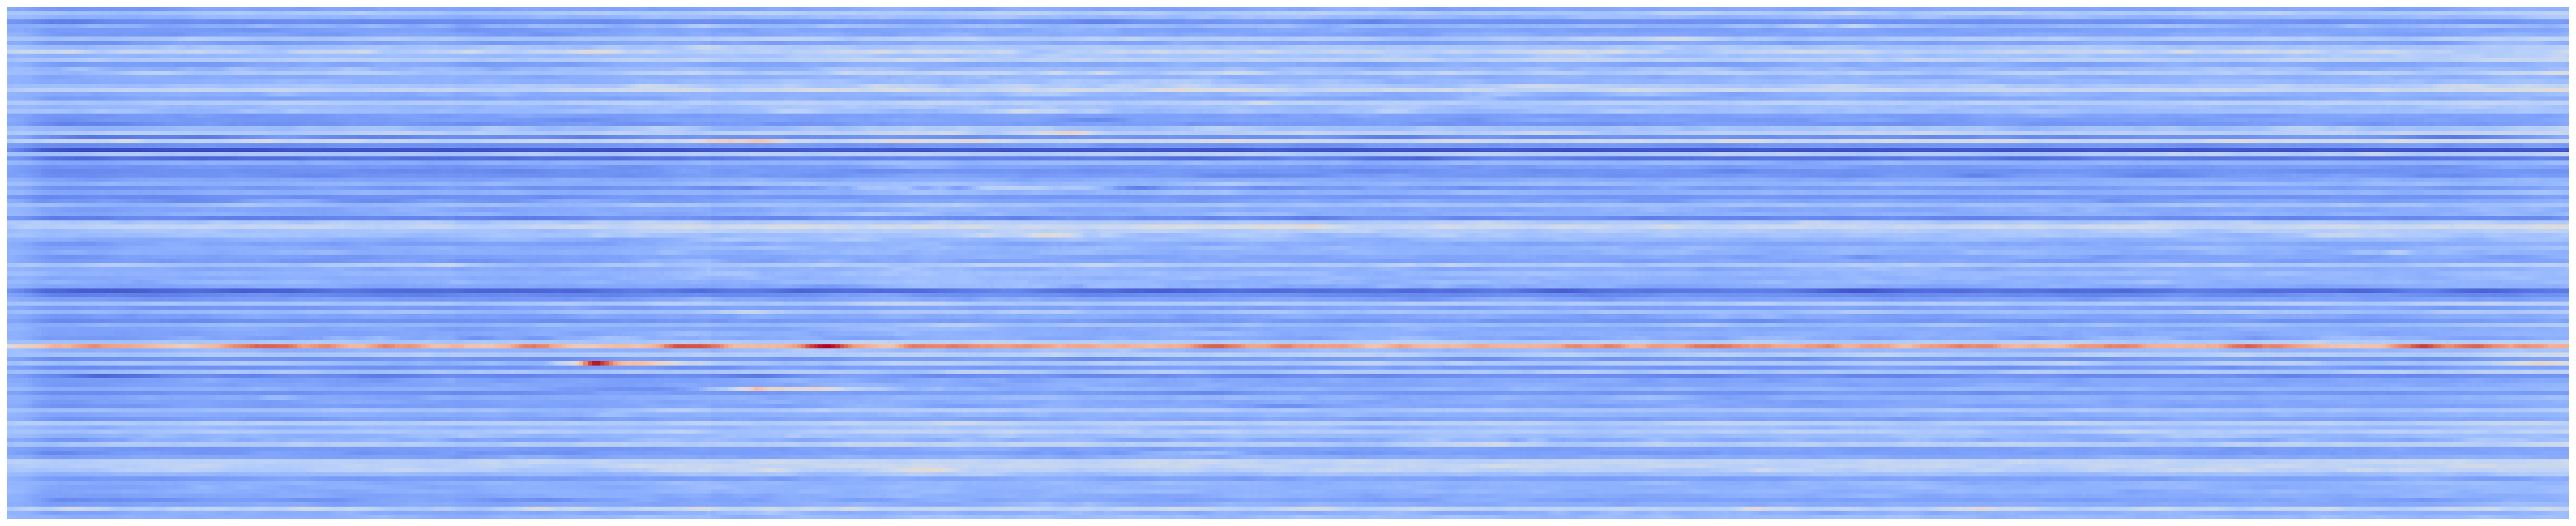

In [137]:
ROIS=120
rois_x = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))
rois_y = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))

imshow(y_hat_p[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(y_bar_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")   
imshow(fused[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(gt_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")